In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize']=20,10
from keras.models import Sequential
from keras.layers import LSTM,Dropout,Dense
from sklearn.preprocessing import MinMaxScaler

In [69]:
df=pd.read_csv("C:\\Users\\LOQ\\Desktop\\datasets\\NSE-Tata-Global-Beverages-Limited.csv")
df.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-10-08,208.00,222.25,206.85,216.00,215.15,4642146.0,10062.83
1,2018-10-05,217.00,218.60,205.90,210.25,209.20,3519515.0,7407.06
2,2018-10-04,223.50,227.80,216.15,217.25,218.20,1728786.0,3815.79
3,2018-10-03,230.00,237.50,225.75,226.45,227.60,1708590.0,3960.27
4,2018-10-01,234.55,234.60,221.05,230.30,230.90,1534749.0,3486.05


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  1235 non-null   object 
 1   Open                  1235 non-null   float64
 2   High                  1235 non-null   float64
 3   Low                   1235 non-null   float64
 4   Last                  1235 non-null   float64
 5   Close                 1235 non-null   float64
 6   Total Trade Quantity  1235 non-null   float64
 7   Turnover (Lacs)       1235 non-null   float64
dtypes: float64(7), object(1)
memory usage: 77.3+ KB


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1235 entries, 2018-10-08 to 2013-10-08
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  1235 non-null   datetime64[ns]
 1   Open                  1235 non-null   float64       
 2   High                  1235 non-null   float64       
 3   Low                   1235 non-null   float64       
 4   Last                  1235 non-null   float64       
 5   Close                 1235 non-null   float64       
 6   Total Trade Quantity  1235 non-null   float64       
 7   Turnover (Lacs)       1235 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 86.8 KB


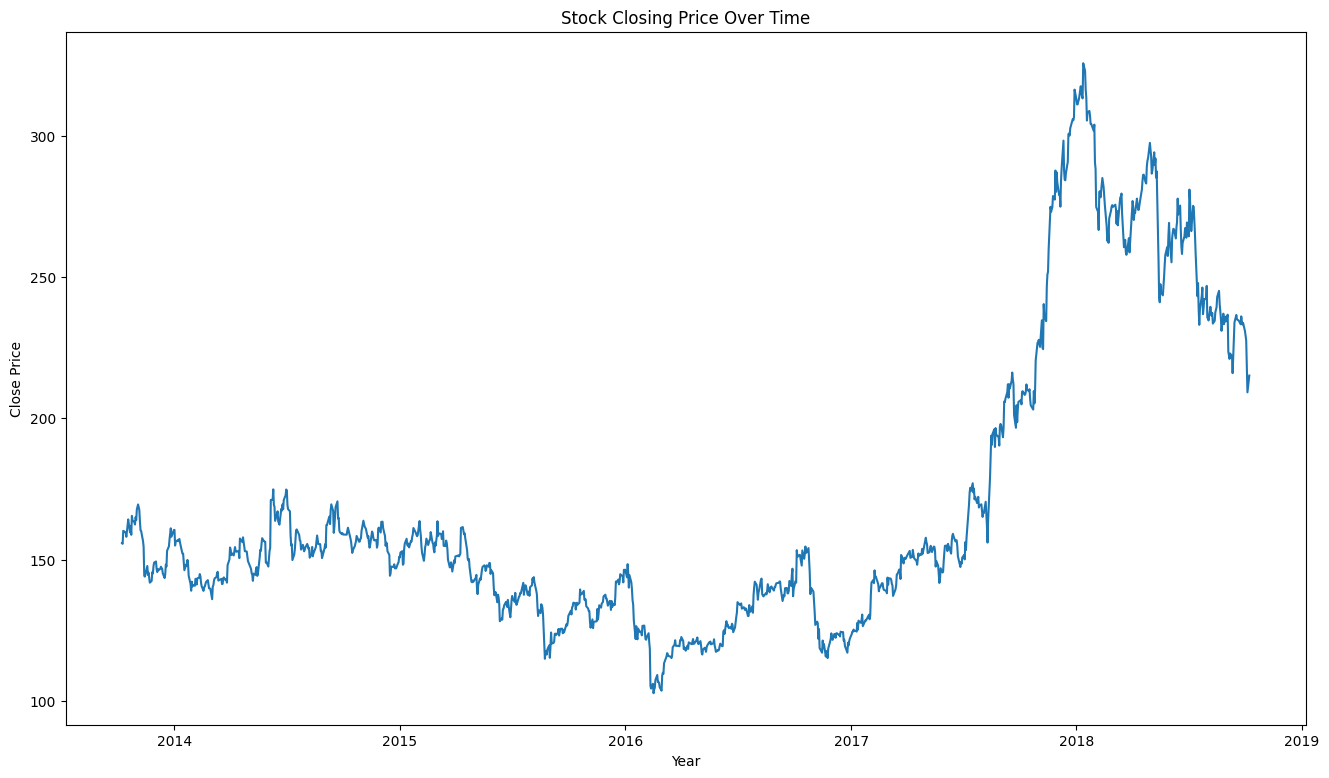

In [71]:
#coverted Date from FLOAT to DAETETIME datatype

df["Date"] = pd.to_datetime(df["Date"], errors='coerce')
df.index=df["Date"]
df.head()
df.info()

# ploting graph of only close from data
plt.figure(figsize=(16,9))
plt.plot(df["Close"],label='Close Price History')
plt.title("Stock Closing Price Over Time")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.show()

In [72]:
#sorting data on basis of date in ASCENDING order
data = df.sort_index(ascending = True,axis=0)

#making new dataset which includes only Date and Close column
new_dataset=pd.DataFrame(index=range(0,len(df)),columns=['Date','Close'])
new_dataset = data[['Date', 'Close']].reset_index(drop=True)
new_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1235 non-null   datetime64[ns]
 1   Close   1235 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.4 KB


In [73]:
# set date as index
new_dataset.set_index("Date", inplace=True)

# split before scaling
train_data = new_dataset[:987]
valid_data = new_dataset[987:]

# scaling
scaler = MinMaxScaler(feature_range=(0,1))
scaled_train_data = scaler.fit_transform(train_data)

x_train_data = []
y_train_data = []

for i in range(60, len(scaled_train_data)):
    x_train_data.append(scaled_train_data[i-60:i, 0])
    y_train_data.append(scaled_train_data[i, 0])

# convert to numpy
x_train_data = np.array(x_train_data)
y_train_data = np.array(y_train_data)

# reshape (CORRECT
x_train_data = np.reshape(
    x_train_data,
    (x_train_data.shape[0], x_train_data.shape[1], 1)
)

In [74]:
lstm_model = Sequential()
lstm_model.add(LSTM(units = 150 , return_sequences = True, input_shape=(x_train_data.shape[1],1)))
lstm_model.add(LSTM(units = 150))
lstm_model.add(Dense(1))

inputs_data=new_dataset[len(new_dataset)-len(valid_data)-60:].values
inputs_data=inputs_data.reshape(-1,1)
inputs_data=scaler.transform(inputs_data)

lstm_model.compile(loss='mean_squared_error',optimizer='adam')
lstm_model.fit(x_train_data,y_train_data,epochs=5,batch_size=2,verbose=2)

Epoch 1/5


C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


464/464 - 22s - 48ms/step - loss: 0.0047
Epoch 2/5
464/464 - 20s - 43ms/step - loss: 0.0018
Epoch 3/5
464/464 - 21s - 44ms/step - loss: 0.0014
Epoch 4/5
464/464 - 21s - 44ms/step - loss: 9.7145e-04
Epoch 5/5
464/464 - 20s - 44ms/step - loss: 0.0010


In [75]:
X_test= []

#the data will loop help to predict the ith value(i.e 1st iteration loop will work it 0,59 and
#will predict the 60th) used for testing data
for i in range(60, inputs_data.shape[0]):
    X_test.append(inputs_data[i-60:i, 0])
X_test=np.array(X_test)

#now converting the data to numpy array
X_test=np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

#used lstm for predicting CLOSE price  
predicted_closing_price = lstm_model.predict(X_test)

#now inversing scaler(0 ,1 form) to normal values for input 
predicted_closing_price=scaler.inverse_transform(predicted_closing_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step


In [76]:
lstm_model.save("lstm_stock_model_saved.h5")

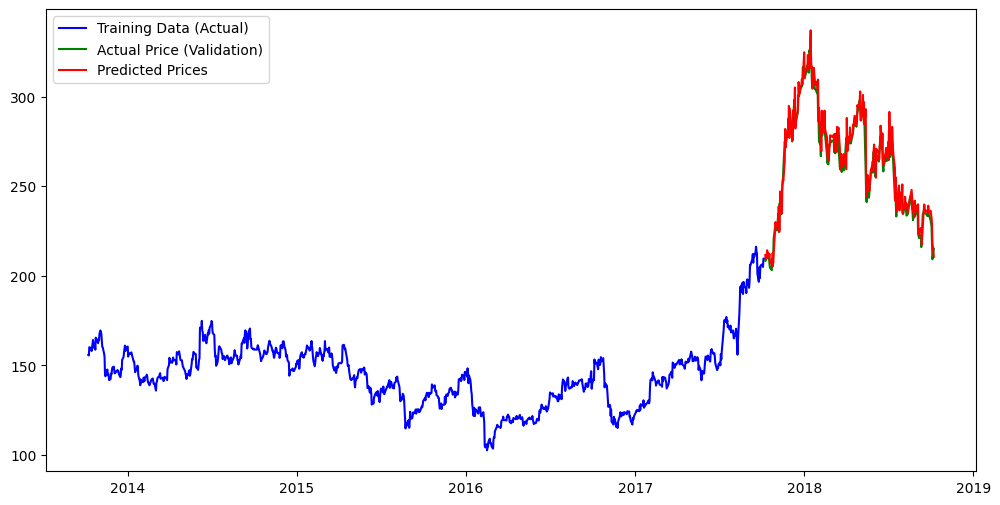

In [80]:
train_data=new_dataset[:987]
# valid_data=new_dataset[987:] #contains actual data 
valid_data = new_dtrain_data = new_dataset[:987]

valid_data = new_dataset[987:].copy()
valid_data.loc[:, 'Prediction'] = predicted_closing_price

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Training data
plt.plot(train_data["Close"], label="Training Data (Actual)", color="blue")

# Validation actual
plt.plot(valid_data["Close"], label="Actual Price (Validation)", color="green")

# Prediction
plt.plot(valid_data["Prediction"], label="Predicted Prices", color="red")

plt.legend()
plt.show()